# Transfer-Ready Model Benchmark and Marker Audit

## tl;dr

This notebook compares the full **2,000-gene Arabidopsis model** with the **340-gene model that has high- or medium-confidence Wolffia orthologs**.

The restricted model retains useful broad-program signal, but its performance is lower and it correctly leaves more cells ambiguous. Logistic-regression balanced accuracy declines from **0.650 to 0.528**, random-forest balanced accuracy declines from **0.588 to 0.474**, and independent-root consensus acceptance declines from **39.3% to 26.5%**.

Marker transfer is strongest for reproductive/floral, transport/water-balance, and photosynthetic programs. Stress, epidermal, and especially vascular interpretation need expanded family-aware orthology analysis before they can support strong biological claims.

**Decision:** retain the full model as the Arabidopsis benchmark, but use only the conservative 340-gene model for future Wolffia transfer.

## Context & Methods

### Scientific question

Can an Arabidopsis-trained broad-program classifier still distinguish biological programs after restricting its features to genes with reliable Wolffia counterparts?

### Comparison design

- **Full model:** 2,000 shared highly variable Arabidopsis genes.
- **Transfer-ready model:** 340 genes with high- or medium-confidence reciprocal Arabidopsis–Wolffia protein mappings.
- **Reference:** 4,727 GSE123818 wild-type Arabidopsis root cells.
- **Independent transfer check:** 2,085 processed GSE121619 Arabidopsis root cells.
- **Models:** class-balanced logistic regression and random forest after PCA.
- **Validation:** entire Leiden clusters are held out, reducing leakage between related cells.

### Key assumptions and limitations

The target labels are broad, marker-derived cluster pseudo-labels rather than expert-curated cell identities. Consequently, the benchmark measures recovery of those broad programs, not definitive cell-type annotation accuracy. Protein-sequence orthology supports cross-species comparability, but does not prove conserved expression or function.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")

def find_repo_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from the repository or its notebooks directory.")

REPO_ROOT = find_repo_root(Path.cwd())
FULL_DIR = REPO_ROOT / "results" / "root_reference_consensus"
TRANSFER_DIR = REPO_ROOT / "results" / "root_reference_consensus_ortholog_restricted"
MARKER_PATH = REPO_ROOT / "data" / "metadata" / "wolffia_program_marker_orthologs.csv"

print("Repository:", REPO_ROOT)
for required in [FULL_DIR, TRANSFER_DIR, MARKER_PATH]:
    assert required.exists(), f"Missing required input: {required}"
print("All required inputs are available.")

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
All required inputs are available.


## Data

The benchmark summaries and metrics were generated by `scripts/27_root_reference_consensus.py`. The marker table was generated by reciprocal DIAMOND searches in `scripts/29_build_arabidopsis_wolffia_orthologs.py`. This notebook reads those tracked outputs rather than retraining the models.

In [2]:
def load_benchmark(directory: Path, feature_set: str):
    metrics = pd.read_csv(directory / "model_comparison_summary.csv")
    metrics.insert(0, "feature_set", feature_set)
    with open(directory / "benchmark_summary.json", encoding="utf-8") as handle:
        summary = json.load(handle)
    return metrics, summary

full_metrics, full_summary = load_benchmark(FULL_DIR, "Full (2,000 genes)")
transfer_metrics, transfer_summary = load_benchmark(TRANSFER_DIR, "Transfer-ready (340 genes)")
metrics = pd.concat([full_metrics, transfer_metrics], ignore_index=True)

display(metrics[[
    "feature_set", "model", "accuracy", "balanced_accuracy", "macro_f1",
    "calibrated_expected_calibration_error"
]].round(3))

,feature_set,model,accuracy,balanced_accuracy,macro_f1,calibrated_expected_calibration_error
0,"Full (2,000 genes)",logistic_regression,0.720,0.650,0.637,0.055
1,"Full (2,000 genes)",random_forest,0.698,0.588,0.586,0.028
2,Transfer-ready (340 genes),logistic_regression,0.635,0.528,0.535,0.078
3,Transfer-ready (340 genes),random_forest,0.631,0.474,0.463,0.099


## Results

### 1. Predictive performance

Balanced accuracy gives equal weight to each program and is especially important here because the pseudo-label classes are unequal. Macro F1 also weights each class equally while requiring both precision and recall.

In [3]:
comparison_rows = []
for model in sorted(metrics["model"].unique()):
    full = full_metrics.loc[full_metrics["model"] == model].iloc[0]
    restricted = transfer_metrics.loc[transfer_metrics["model"] == model].iloc[0]
    for metric in ["accuracy", "balanced_accuracy", "macro_f1", "calibrated_expected_calibration_error"]:
        comparison_rows.append({
            "model": model,
            "metric": metric,
            "full_value": full[metric],
            "transfer_ready_value": restricted[metric],
            "absolute_change": restricted[metric] - full[metric],
        })

performance_changes = pd.DataFrame(comparison_rows)
display(performance_changes.round(3))

,model,metric,full_value,transfer_ready_value,absolute_change
0,logistic_regression,accuracy,0.720,0.635,-0.085
1,logistic_regression,balanced_accuracy,0.650,0.528,-0.123
2,logistic_regression,macro_f1,0.637,0.535,-0.103
3,logistic_regression,calibrated_expected_calibration_error,0.055,0.078,0.022
4,random_forest,accuracy,0.698,0.631,-0.066
5,random_forest,balanced_accuracy,0.588,0.474,-0.114
6,random_forest,macro_f1,0.586,0.463,-0.123
7,random_forest,calibrated_expected_calibration_error,0.028,0.099,0.071


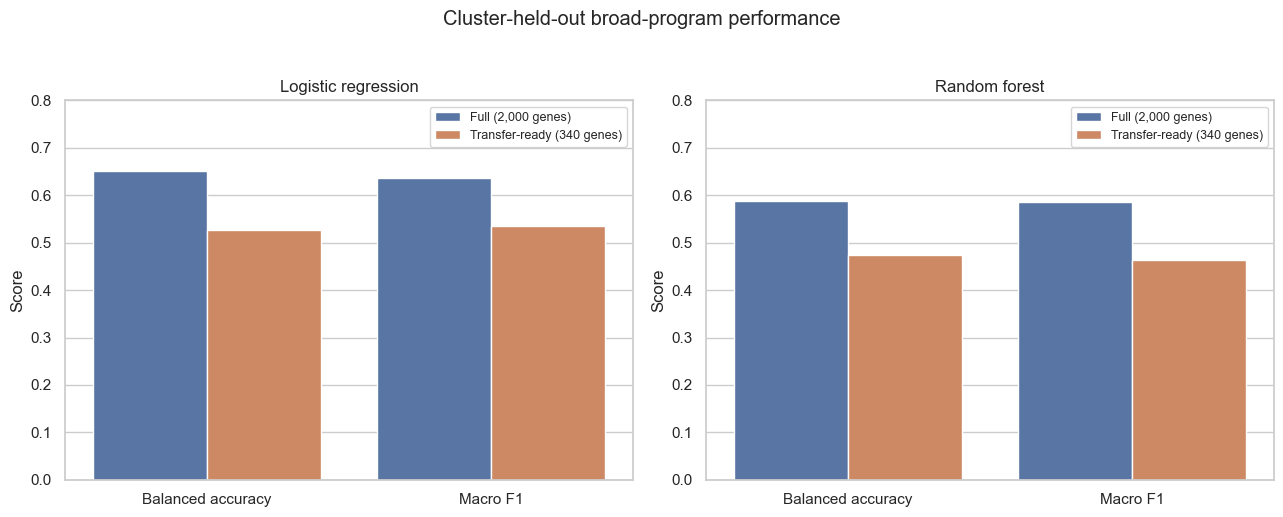

In [4]:
plot_metrics = metrics.melt(
    id_vars=["feature_set", "model"],
    value_vars=["balanced_accuracy", "macro_f1"],
    var_name="metric", value_name="score",
)
plot_metrics["model"] = plot_metrics["model"].replace({
    "logistic_regression": "Logistic regression",
    "random_forest": "Random forest",
})
plot_metrics["metric"] = plot_metrics["metric"].replace({
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, model in zip(axes, ["Logistic regression", "Random forest"]):
    subset = plot_metrics.loc[plot_metrics["model"] == model]
    sns.barplot(data=subset, x="metric", y="score", hue="feature_set", ax=axis)
    axis.set_ylim(0, 0.8)
    axis.set_title(model)
    axis.set_xlabel("")
    axis.set_ylabel("Score")
    axis.legend(title="", fontsize=9)
fig.suptitle("Cluster-held-out broad-program performance", y=1.03)
fig.tight_layout()
plt.show()

**Interpretation.** Both algorithms lose performance after feature restriction, so the missing 1,660 genes contained useful discriminating information. The similar direction of change across two different algorithms makes this less likely to be an algorithm-specific artifact. The restricted model nevertheless remains above naive chance for three balanced classes, supporting cautious coarse-program transfer rather than definitive cell-type annotation.

### 2. Confidence calibration

Expected calibration error asks whether a prediction reported with a given confidence is correct at approximately that frequency. Lower values are better. Restriction increases calibrated error, especially for random forest, so confidence thresholds remain necessary.

feature_set,"Full (2,000 genes)",Transfer-ready (340 genes)
model,,
logistic_regression,0.055,0.078
random_forest,0.028,0.099


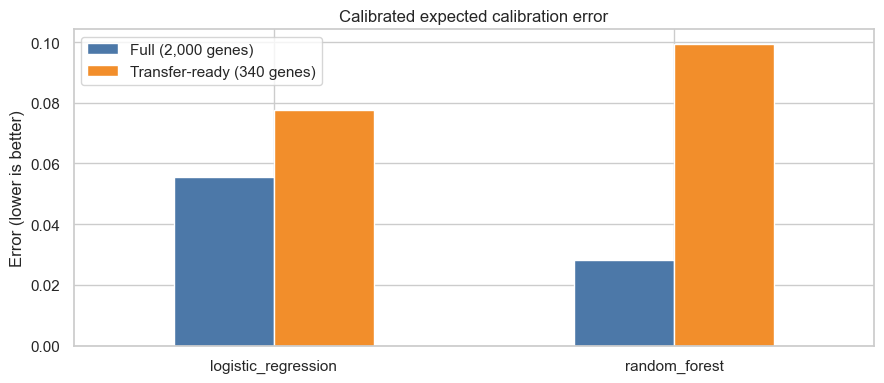

In [5]:
calibration = metrics.pivot(
    index="model", columns="feature_set", values="calibrated_expected_calibration_error"
)
display(calibration.round(3))

ax = calibration.plot(kind="bar", figsize=(9, 4), color=["#4C78A8", "#F28E2B"])
ax.set_title("Calibrated expected calibration error")
ax.set_ylabel("Error (lower is better)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.show()

### 3. Independent-root consensus acceptance

A GSE121619 cell is accepted only when logistic regression and random forest agree, both confidence thresholds pass, the prediction agrees with marker-module evidence, and the marker-score margin is sufficient. Rejected cells remain explicitly ambiguous.

,feature_set,accepted_cells,ambiguous_cells,acceptance_rate,acceptance_percent
0,"Full (2,000 genes)",820,1265,0.4,39.3
1,Transfer-ready (340 genes),552,1533,0.3,26.5


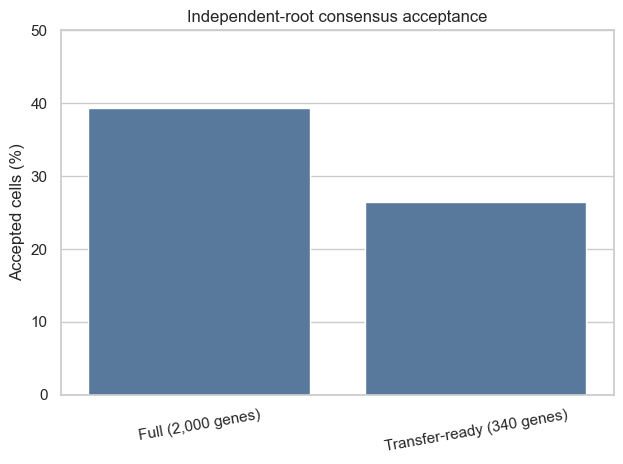

In [6]:
consensus = pd.DataFrame([
    {
        "feature_set": "Full (2,000 genes)",
        "accepted_cells": full_summary["n_consensus_accepted"],
        "ambiguous_cells": full_summary["n_second_root_cells"] - full_summary["n_consensus_accepted"],
        "acceptance_rate": full_summary["consensus_acceptance_rate"],
    },
    {
        "feature_set": "Transfer-ready (340 genes)",
        "accepted_cells": transfer_summary["n_consensus_accepted"],
        "ambiguous_cells": transfer_summary["n_second_root_cells"] - transfer_summary["n_consensus_accepted"],
        "acceptance_rate": transfer_summary["consensus_acceptance_rate"],
    },
])
display(consensus.assign(acceptance_percent=100 * consensus["acceptance_rate"]).round(1))

plot_data = consensus.copy()
plot_data["acceptance_percent"] = 100 * plot_data["acceptance_rate"]
ax = sns.barplot(data=plot_data, x="feature_set", y="acceptance_percent", color="#4C78A8")
ax.set_ylim(0, 50)
ax.set_title("Independent-root consensus acceptance")
ax.set_ylabel("Accepted cells (%)")
ax.set_xlabel("")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Interpretation.** Acceptance decreases by 12.9 percentage points, from 820 to 552 cells. This is not automatically a failure: the conservative model is admitting that many cells cannot be supported using the cross-species-compatible evidence currently available. Preserving this ambiguous category is scientifically safer than forcing every Wolffia cell into an Arabidopsis program.

### 4. Biological-program marker coverage

Marker mappings are separated into:

- **Transfer-ready:** high- or medium-confidence reciprocal match.
- **Family-level candidate:** plausible directional match, but one-to-one orthology is unresolved.
- **Unresolved:** no acceptable match or insufficient sequence coverage.

Family-level candidates are useful for follow-up orthogroup or gene-tree analysis, but they are not inserted into the strict classifier.

In [7]:
markers = pd.read_csv(MARKER_PATH)

def classify_marker(confidence: str) -> str:
    if confidence in {"high", "medium"}:
        return "transfer_ready"
    if confidence == "low":
        return "family_level_candidate"
    return "unresolved"

markers["transfer_category"] = markers["mapping_confidence"].fillna("unmapped").map(classify_marker)
coverage = (
    markers.groupby(["program", "transfer_category"]).size().unstack(fill_value=0)
    .reindex(columns=["transfer_ready", "family_level_candidate", "unresolved"], fill_value=0)
)
coverage["total_markers"] = coverage.sum(axis=1)
coverage["transfer_ready_percent"] = 100 * coverage["transfer_ready"] / coverage["total_markers"]
coverage["candidate_or_better_percent"] = 100 * (
    coverage["transfer_ready"] + coverage["family_level_candidate"]
) / coverage["total_markers"]
display(coverage.round(1))

transfer_category,transfer_ready,family_level_candidate,unresolved,total_markers,transfer_ready_percent,candidate_or_better_percent
program,,,,,,
abiotic_stress_response,1,1,4,6,16.7,33.3
developmental_transition,2,2,2,6,33.3,66.7
epidermal_or_surface_identity,1,4,0,5,20.0,100.0
photosynthetic_or_assimilation,3,3,0,6,50.0,100.0
proliferative_or_meristematic,2,3,0,5,40.0,100.0
reproductive_or_floral,3,0,0,3,100.0,100.0
transport_interface_or_water_balance,3,2,0,5,60.0,100.0
vascular_like_or_transport,0,6,3,9,0.0,66.7


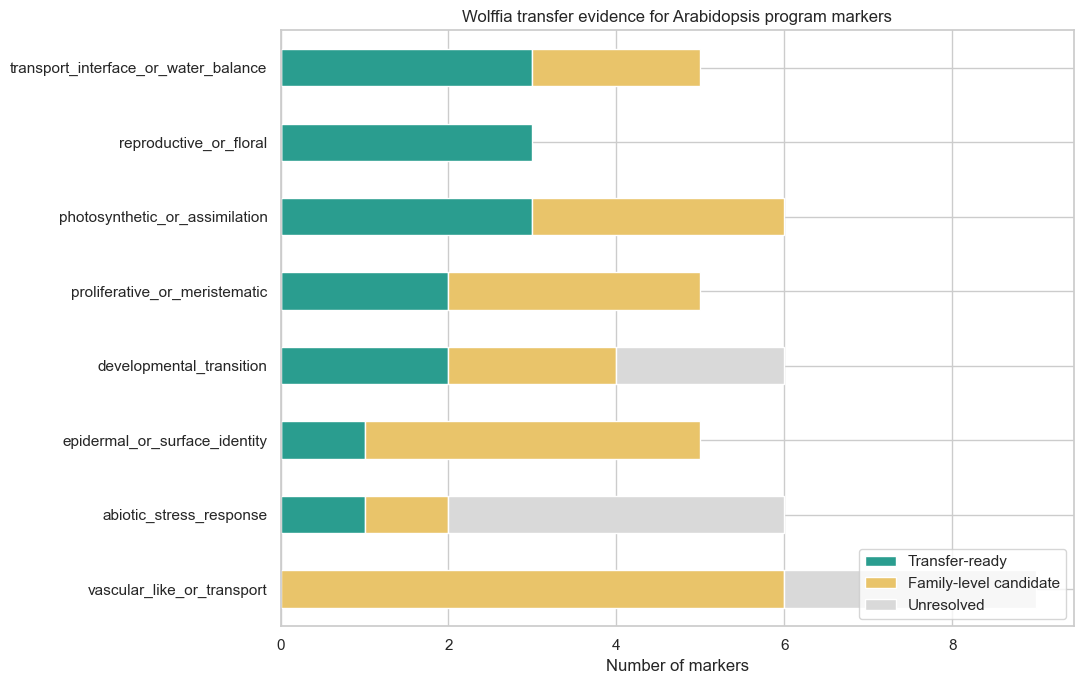

In [8]:
coverage_plot = coverage[["transfer_ready", "family_level_candidate", "unresolved"]].copy()
coverage_plot = coverage_plot.sort_values("transfer_ready")
coverage_plot.columns = ["Transfer-ready", "Family-level candidate", "Unresolved"]
ax = coverage_plot.plot(
    kind="barh", stacked=True, figsize=(11, 7),
    color=["#2A9D8F", "#E9C46A", "#D9D9D9"],
)
ax.set_title("Wolffia transfer evidence for Arabidopsis program markers")
ax.set_xlabel("Number of markers")
ax.set_ylabel("")
ax.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation.** Reproductive/floral markers have complete strict coverage, while transport/water-balance and photosynthetic programs retain 60% and 50%. Proliferative and developmental programs are incomplete but still have multiple strict markers. Stress has only one strict marker. Vascular has no strict reciprocal marker, but six family-level candidates suggest that the apparent gap may reflect duplicated gene families and one-to-many relationships rather than complete biological absence.

### 5. Inspect weak programs and candidate genes

The next table identifies the exact Wolffia candidates behind the weakest marker panels. These candidates should be reviewed biologically and with orthogroup or phylogenetic methods before use.

In [9]:
weak_programs = [
    "abiotic_stress_response",
    "epidermal_or_surface_identity",
    "vascular_like_or_transport",
]
candidate_columns = [
    "program", "gene", "gene_id", "priority", "wolffia_gene_symbol",
    "wolffia_ncbi_gene_id", "wolffia_product", "percent_identity",
    "query_coverage", "subject_coverage", "reciprocal_best_hit",
    "orthology_status", "mapping_confidence", "transfer_category",
]
weak_candidates = markers.loc[markers["program"].isin(weak_programs), candidate_columns]
display(weak_candidates.sort_values(["program", "transfer_category", "gene"]).reset_index(drop=True))

,program,gene,gene_id,priority,wolffia_gene_symbol,wolffia_ncbi_gene_id,wolffia_product,percent_identity,query_coverage,subject_coverage,reciprocal_best_hit,orthology_status,mapping_confidence,transfer_category
0,abiotic_stress_response,ZAT12,AT5G59820,high,LOC144701411,144701411.0,C2H2-type zinc finger family protein,45.9,87.0,82.5,False,directional_best_hit,low,family_level_candidate
1,abiotic_stress_response,HSP101,AT1G74310,medium,HSP101,144709454.0,heat shock protein 101,81.6,99.3,99.7,True,reciprocal_best_hit,high,transfer_ready
2,abiotic_stress_response,COR15A,AT2G42540,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_hit,unmapped,unresolved
3,abiotic_stress_response,DREB2A,AT5G05410,high,LOC144714214,144714214.0,uncharacterized protein LOC144714214,68.9,34.6,33.4,True,below_threshold,unmapped,unresolved
4,abiotic_stress_response,ERD10,AT1G20450,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_hit,unmapped,unresolved
5,abiotic_stress_response,RD29A,AT5G52310,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_hit,unmapped,unresolved
6,epidermal_or_surface_identity,ATML1,AT4G21750,medium,LOC144700924,144700924.0,homeobox-leucine zipper protein ROC2-like,67.0,96.9,93.1,False,directional_best_hit,low,family_level_candidate
7,epidermal_or_surface_identity,COBL9,AT5G49270,medium,COBL10,144707687.0,COBRA-like protein 10 precursor,52.4,91.9,91.2,False,directional_best_hit,low,family_level_candidate
8,epidermal_or_surface_identity,EXP7,AT1G12560,medium,EXPA4,144706643.0,expansin A4,52.6,94.3,95.4,False,directional_best_hit,low,family_level_candidate
9,epidermal_or_surface_identity,WER,AT5G14750,high,LOC144702575,144702575.0,transcription factor MYB1-like,69.6,50.2,41.0,False,directional_best_hit,low,family_level_candidate


## Takeaways

1. **The 340-gene model is usable but deliberately conservative.** It retains coarse predictive information while producing more ambiguous results.
2. **The full model remains the within-Arabidopsis benchmark.** It should not be applied directly to Wolffia because most features lack sufficiently reliable one-to-one mappings.
3. **Program transferability is uneven.** Photosynthesis, water balance, proliferation, development, and reproductive regulation have multiple strict mappings; stress and vascular interpretations remain fragile.
4. **Zero strict vascular markers does not mean vascular biology is absent.** Six directional family matches need orthogroup or gene-tree resolution.
5. **Future Wolffia predictions must retain an ambiguous class** and should require agreement between models, adequate confidence, marker support, and sufficient detected ortholog coverage.

### Next computational work

- Build family-aware orthogroups for vascular, epidermal, and stress markers.
- Expand weak panels using conserved pathway members rather than single Arabidopsis marker genes.
- Once Wolffia single-cell matrices are available, measure per-cell detection of the 340 features before classification.
- Compare transferred predictions with unsupervised Wolffia clusters and Wolffia-native differential-expression markers.